<a href="https://colab.research.google.com/github/MishaVertCV/DS/blob/main/VK.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<h1>Вопрос 3<span class="tocSkip"></span></h1>

Для начала импортируем необходимые библиотеки для выполнения задания:

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

Теперь прочитаем датасет и выведем его:

In [3]:
df = pd.read_csv('/content/analytics_test.csv')
df.info()
df.head(10)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   Unnamed: 0      20000 non-null  int64 
 1   user_id         20000 non-null  int64 
 2   sex             20000 non-null  object
 3   age             20000 non-null  int64 
 4   platform        20000 non-null  object
 5   query_id        20000 non-null  int64 
 6   query_text      20000 non-null  object
 7   query_type      20000 non-null  object
 8   event           20000 non-null  object
 9   click_position  20000 non-null  int64 
 10  doc_type        15042 non-null  object
 11  view_time       20000 non-null  int64 
dtypes: int64(6), object(6)
memory usage: 1.8+ MB


,Unnamed: 0,user_id,sex,age,platform,query_id,query_text,query_type,event,click_position,doc_type,view_time
0,0,96422511,female,68,android,89656828,передачи о новых технологиях,show,share,6,playlist,0
1,1,45247030,male,62,android_tv,89784877,автопрому новости,news,search,0,NaN,0
2,2,79572413,male,12,web,10555855,логистическое законодательство,news,search,0,NaN,0
3,3,821317,female,58,android_tv,72054848,банковские премии новости,news,search,0,NaN,0
4,4,6206023,female,24,android,20838049,вики шоу аманда,show,subscribe,7,author,0
5,5,8004249,anonym,0,android,19760211,как купить билеты на Грибов,music,tap,1,author,0
6,6,11617125,female,66,android_tv,59650610,5+1 шоу парень бедный,show,subscribe,8,video,0
7,7,79473329,anonym,0,smart_tv,569617620,биография Мэрилин Монро,films,tap,5,clip,0
8,8,17370723,anonym,0,android,46720550,поездка или поездочка шоу истории,show,subscribe,9,video,0
9,9,30126713,female,29,web,29645901,автозаконодательство новости,news,view,2,clip,183


Из следующих данных сразу видно, что в столбце doc_type есть пропуски (NaN), также в первых 10 строках время просмотра ("view_time") чаще всего равно 0, но это скорее всего связано с тем, это не действие просмотра, т. е. в столбце "event" нет значения "view". Также есть нули в стобце "age", возможно пользователи не указывали свой возраст.

## Предобработка данных

### Проверка и обработка пропусков

Определим количество пропущенных значений в датафрейме:

In [4]:
df.isna().sum()

,0
Unnamed: 0,0
user_id,0
sex,0
age,0
platform,0
query_id,0
query_text,0
query_type,0
event,0
click_position,0


Количество пропущенных значений составляет 4958 в столбце "doc_type", посмотрим сколько всего строк в датафрейме и посчитаем процент пропусков, чтобы понять можно ли пренебречь этими данными.

In [5]:
df.shape[0]

20000

In [6]:
print((df["doc_type"].isna().sum()/df.shape[0]) * 100, '%')

24.79 %


Обычно нельзя удалять больше 10% датафрейма, поэтому просто оставим строки с пропущенными значениями.

### Проверим датафрейм на дубликаты

In [7]:
df.duplicated().sum()

np.int64(0)

Дубликаты не найдены, поэтому двигаемся дальше.

### Проверим датафрейм на выбросы и "странные" значения

Для начала посмотрим на количество нулевых значений в столбце "view_time" ко всему датафрейму:

In [8]:
per_zero_val = df.query('view_time == 0')['view_time'].count()/df.shape[0] * 100
print('{0:.2f}'.format(per_zero_val), "%")

85.41 %


Большинство результатов поиска (85.41%) с нулевым временем просмотра, что кажется необычным, поэтому стоит проверить столбец "event" с нулевым временем просмота:

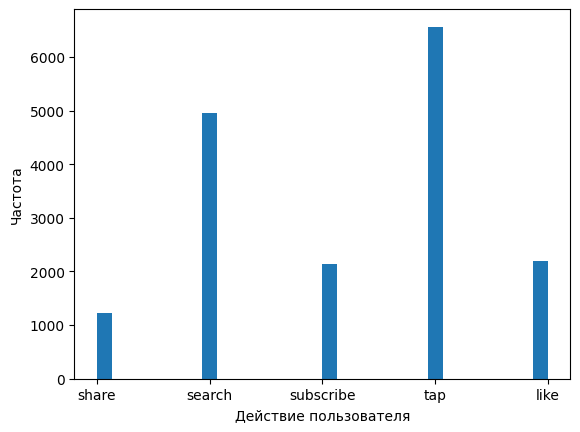

In [9]:
plt.hist(df.query('view_time == 0')['event'], bins=30)
plt.xlabel("Действие пользователя")
plt.ylabel("Частота")
plt.show()

Так как действия view, т. е. просмотра видео не было, то это не ошибка. Большинсво пользователей делают действия не просматривая видео (подписываются на канал, ставят лайки, делятся видео и т. д.).

Построим гистограмму для времени просмотра без нулевого времени просмотра, так как это были другие действия и проверим, есть ли выбросы:

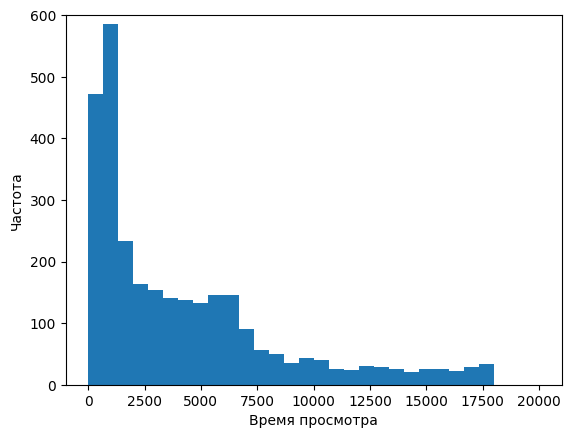

In [10]:
plt.hist(df['view_time'], bins=30, range=(1, 20000))
plt.ylim(0, 600)
plt.xlabel("Время просмотра")
plt.ylabel("Частота")
plt.show()

Проверим есть ли значения выше 18000 секунд, которых не видно на гистограмме, будем считать их выбросами:

In [11]:
df.query('view_time > 18000')['view_time'].count()

np.int64(0)

Теперь проверим значения столбца "age", так как там были нулевые значения. Так как возраст человека, который пользуется площадкой не может быть равен нулю, стоит эти значения воспринимать как пропуски. Сначала подсчитаем их количество:

In [12]:
df.query('age == 0')['age'].count()

np.int64(4733)

Строк с нулевым значением возраста точно больше 10%, поэтому просто удалить из датафрейма их нельзя, но медианный возраст пользователей будем считать без учёта этих значений. Проверим ещё "аномальные" значения, будем считать значения "аномальными", если возраст смотрящего видео больше 120 лет, для начала посмотрим гистограмму (без нулевых значений возраста):

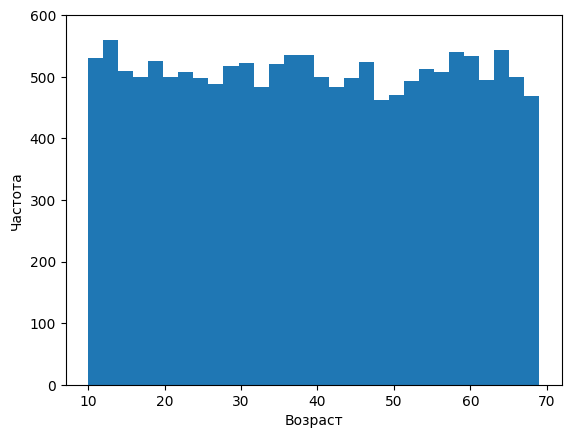

In [13]:
plt.hist(df.query('age != 0')['age'], bins=30)
plt.ylim(0, 600)
plt.xlabel("Возраст")
plt.ylabel("Частота")
plt.show()

Все значения лежат от 10 до 70 лет, что вполне нормально. Также из гистограммы видно, что частота использования поиска не сильно меняется от возраста пользователей. Также посмотрим на boxplot:

<Axes: >

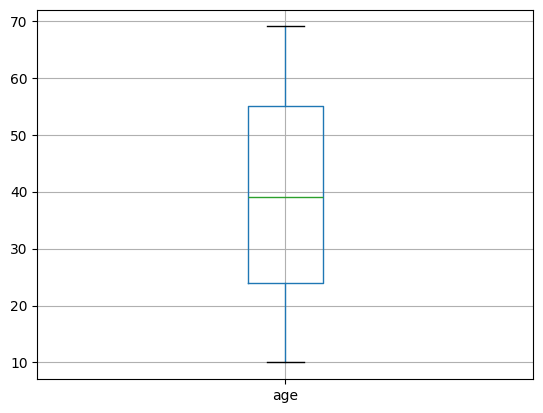

In [14]:
df.query('age != 0')[['age']].boxplot()

На боксплоте явно видно, что никаких выбросов из данных нет, а медианный возраст чуть ниже 40 лет.

## Анализ данных

### Анализ пола пользователей, определение большого количества анонимов в этом столбце

Сначала посмотрим на пол пользователей, пользующихся площадкой:

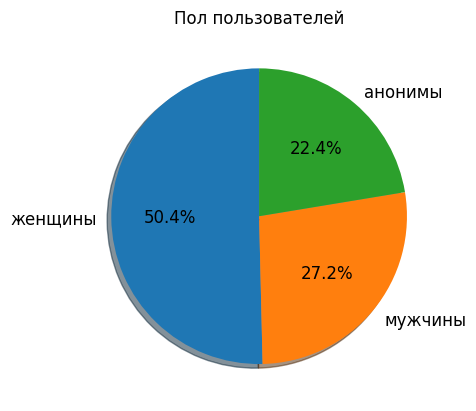

In [15]:
labels = ['женщины', 'мужчины', 'анонимы']
plt.pie(
    df['sex'].value_counts(),
    labels = labels,
    autopct='%1.1f%%',
    shadow=True,
    startangle=90,
    textprops={'fontsize': 12}
)
plt.title('Пол пользователей')
plt.show()

Больше всего площадкой пользуются женщины, мужчины практически в 2 раза меньше, но также есть те пользователи, которые не указывают пол, есть вероятность, что это сильно зависит от платформы, которую они используют, для этого построим heatmap с основными площадками в зависимости от пола:

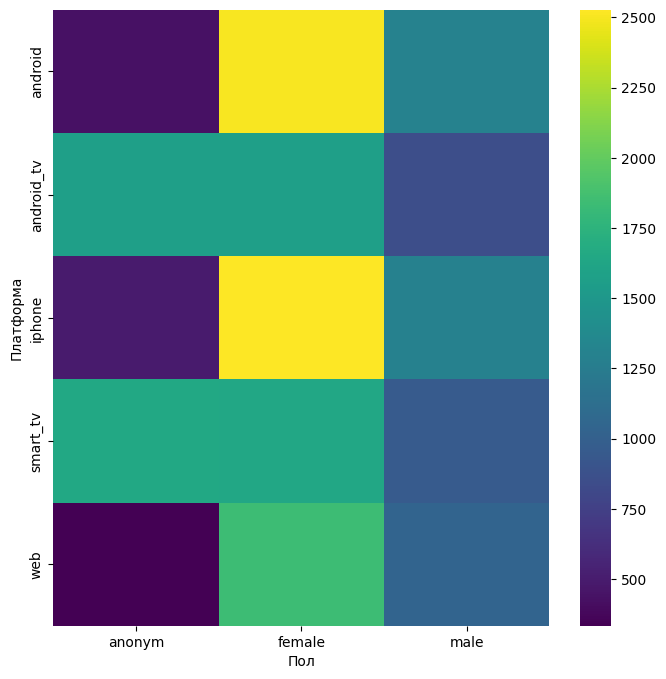

In [16]:
plt.subplots(figsize=(8, 8))
df_2dhist = pd.DataFrame({
    x_label: grp['platform'].value_counts()
    for x_label, grp in df.groupby('sex')
})
sns.heatmap(df_2dhist, cmap='viridis')
plt.xlabel('Пол')
_ = plt.ylabel('Платформа')

Из этого графика видно, что анонимы в основном используют android_tv и smart_tv, скорее всего это означает, что на телевизорах пользователям сложнее зарегистрироваться и для лучшего анализа данных в будущем **лучше придумать способ быстрой и удобной регистрации для пользователей tv**. Также у женщин и мужчин больше действий с iphone и android, что довольно логично, так как люди чаще используют мобильные устройства, чем телевизоры.

### Анализ действий пользователей на сайте

Построим гистограмму действий пользователей на сайте:

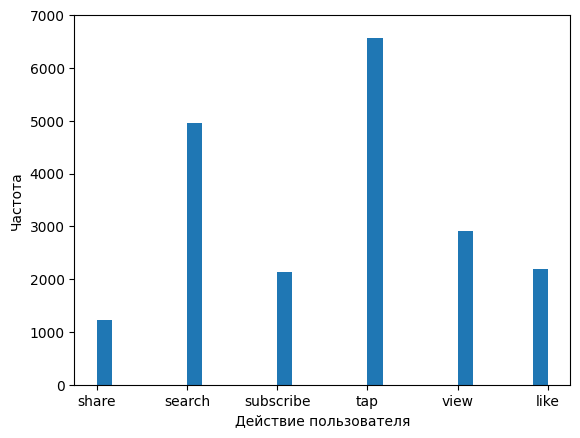

In [17]:
plt.hist(df['event'], bins=30)
plt.ylim(0, 7000)
plt.xlabel("Действие пользователя")
plt.ylabel("Частота")
plt.show()

По данной гистограмме наглядно видно, что больше всего дейтвий составляют клики на айтемы ("tap"). На последнем месте действия поделиться ("share").

Ранее, при обработке данных столбца "age", можно было убедиться, что пользователи разных возрастов делают примерно одинаковое количество действий на сайте. Теперь необходимо проверить

/tmp/ipython-input-18-1932762190.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  engagement_by_age = df.groupby(['age_group', 'event']).size().unstack().fillna(0)


<Figure size 1200x600 with 0 Axes>

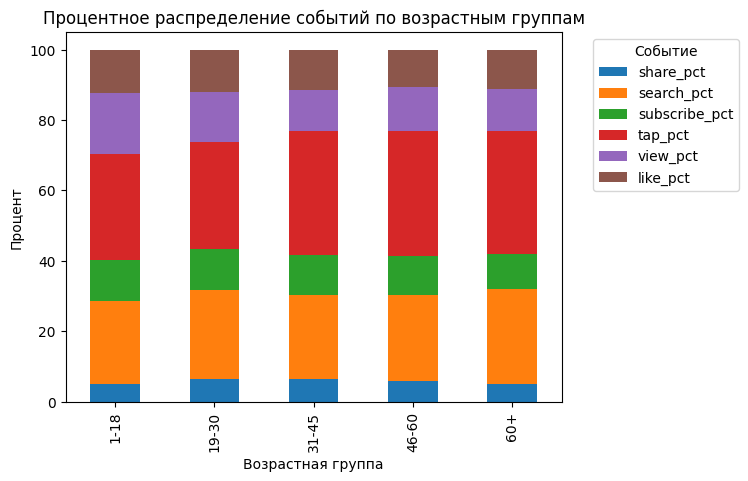

In [18]:
# Создаем возрастные группы
bins = [1, 18, 30, 45, 60, 100]
labels = ['1-18', '19-30', '31-45', '46-60', '60+']
df['age_group'] = pd.cut(df['age'], bins=bins, labels=labels, right=False)

# Анализ вовлеченности по возрастным группам
engagement_by_age = df.groupby(['age_group', 'event']).size().unstack().fillna(0)
engagement_by_age['total'] = engagement_by_age.sum(axis=1)
for col in engagement_by_age.columns[:-1]:
    engagement_by_age[f'{col}_pct'] = engagement_by_age[col] / engagement_by_age['total'] * 100

plt.figure(figsize=(12, 6))
engagement_by_age[['share_pct', 'search_pct', 'subscribe_pct', 'tap_pct', 'view_pct', 'like_pct']].plot(kind='bar', stacked=True)
plt.title('Процентное распределение событий по возрастным группам')
plt.ylabel('Процент')
plt.xlabel('Возрастная группа')
plt.legend(title='Событие', bbox_to_anchor=(1.05, 1))
plt.show()

По графику видно, что **самое большое количество просмотров у возрастной группы до 18 лет, там же меньше всего кликов на айтемы, т. е. в этой возрастной группе поиск работает качественнее всего, так как при небольшом количестве кликов пользователи находят подходящее видео. Пользователям больше 30 лет уже значительно сложнее найти устраивающий их контент, так как "тапов" больше, а просмотров меньше, соответсвенно лайков и подписок тоже меньше. Но действий поделиться больше у людей средних лет (19-45).**

### Анализ темы поиска

Для начала проаналазируем по тему поиска по времени просмотра:

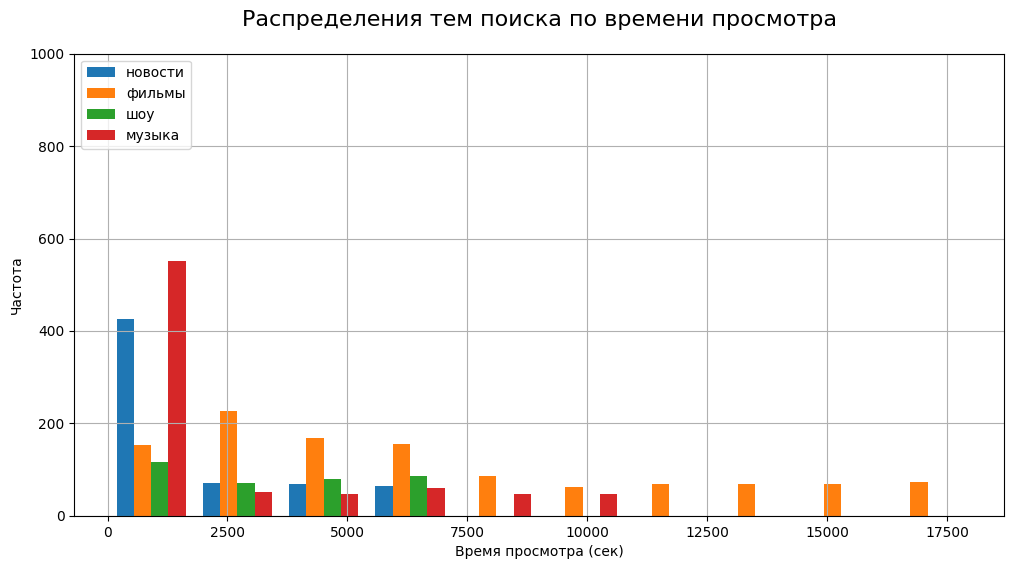

In [30]:
view_time = df.query('event == "view"')

plt.figure(figsize=(12, 6))
news = view_time.query('query_type == "news"')['view_time']
films = view_time.query('query_type == "films"')['view_time']
show = view_time.query('query_type == "show"')['view_time']
music = view_time.query('query_type == "music"')['view_time']
q_type = [news, films, show, music]
label = ['новости', 'фильмы', 'шоу', 'музыка']
plt.hist(q_type, label = label)
plt.legend(loc='upper left')
plt.grid(True)
plt.title('Распределения тем поиска по времени просмотра', fontsize=16, pad=20)
plt.ylim(0, 1000)
plt.ylabel('Частота')
plt.xlabel('Время просмотра (сек)')
plt.show()

Короткое время время слушают музыку (что логично) и новости. Фильмы смотрят больше всего в районе 2500 секунд, что меньше средней продолжительности фильма - примерно 5000 секунд, но это может быть связано с тем, что у пользователей недостаточно времени для просмотра за один раз такого большого контента.

## Вывод

В основном поиск показывает плохое качество по ряду причин:


1.  На платформах связаных с телевидением (android TV, smart TV) огромное количество незарегистрированных пользователей (анонимов). Это может повлиять на рекомендации этой группе людей, а также на поиск. Лучше придумать способ быстрой и удобной регистрации для пользователей TV.
2.  Пользователям больше 30 лет значительно сложнее найти устраивающий их контент, чем более молодым пользователям, так как "тапов" больше, а просмотров меньше, соответсвенно лайков и подписок тоже меньше.
3.  Довольно маленькое в среднем время просмотра новостей может быть из-за не очень хорошего поиска в этой области.






